# Negative Binomial and Poisson GBDT Regression Models


In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import poisson, nbinom

# Statsmodels for regression
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial
from statsmodels.stats.diagnostic import acorr_ljungbox

# Scikit-learn for metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Add project root to path
PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from config import *
from src.data_processing.data_loader import load_and_clean_data
from src.data_processing.spatial_join_fast import perform_spatial_join_fast
from src.feature_engineering.feature_creator import create_segment_features

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

/Users/achchala/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/achchala/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 1. Load and Prepare Data

In [2]:
# Load data
data_dir = PROJECT_ROOT / "data"
collision_data, ksi_data, road_network = load_and_clean_data(data_dir)

print(f"Loaded {len(collision_data)} collision records")
print(f"Loaded {len(ksi_data)} KSI records")
print(f"Loaded {len(road_network)} road segments")

Loaded 618254 collision records
Loaded 18957 KSI records
Loaded 65133 road segments


In [3]:
# Perform spatial join to assign crashes to road segments
segment_crashes = perform_spatial_join_fast(collision_data, ksi_data, road_network)
print(f"Segments with crash data: {len(segment_crashes)}")

Segments with crash data: 65133


In [33]:

# create collision_dates and split_date if they don't exist
if 'collision_dates' not in locals() and 'collision_dates' not in globals():
    print("Creating date splits...")
    collision_dates = pd.to_datetime(collision_data['DATE'], errors='coerce')
    ksi_dates = pd.to_datetime(ksi_data['DATE'], errors='coerce')
    
    # Find split date (80% train, 20% test)
    all_dates = pd.concat([collision_dates, ksi_dates]).dropna()
    split_date = all_dates.quantile(0.8)
    
    print(f"Split date (80th percentile): {split_date}")
    print(f"Train crashes: {all_dates[all_dates < split_date].count()}")
    print(f"Test crashes: {all_dates[all_dates >= split_date].count()}")

# Split collision and KSI data by date
train_collision = collision_data[collision_dates < split_date].copy()
test_collision = collision_data[collision_dates >= split_date].copy()

train_ksi = ksi_data[ksi_dates < split_date].copy()
test_ksi = ksi_data[ksi_dates >= split_date].copy()

# Perform spatial joins separately for train and test
print("\nPerforming spatial joins...")
train_segment_crashes = perform_spatial_join_fast(train_collision, train_ksi, road_network)
test_segment_crashes = perform_spatial_join_fast(test_collision, test_ksi, road_network)

# Create features for train and test
print("Creating features...")
train_features = create_segment_features(train_segment_crashes, road_network)
test_features = create_segment_features(test_segment_crashes, road_network)

print(f"Train segments: {len(train_features)}")
print(f"Test segments: {len(test_features)}")

# Select only road characteristics (no IDs, no addresses)
meaningful_features = [
    'segment_length',
    'road_class_arterial',
    'road_class_collector', 
    'road_class_local',
    'road_class_minor_arterial',
]

# Filter to only features that exist
available_features = [f for f in meaningful_features if f in train_features.columns]
print(f"\nUsing {len(available_features)} meaningful features: {available_features}")

# Prepare X and y with only meaningful features
X_train = train_features[available_features].fillna(0)
y_train = train_features['num_total_crashes'].fillna(0).astype(int)

X_test = test_features[available_features].fillna(0)
y_test = test_features['num_total_crashes'].fillna(0).astype(int)

# Scale features to prevent overflow in exponential
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train = pd.DataFrame(X_train_scaled, columns=available_features, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=available_features, index=X_test.index)

print(f"\nTrain: X shape {X_train.shape}, y shape {y_train.shape}")
print(f"Test: X shape {X_test.shape}, y shape {y_test.shape}")
print(f"\nFeature statistics (scaled):")
print(X_train.describe())


Performing spatial joins...
Creating features...
Train segments: 65133
Test segments: 65133

Using 5 meaningful features: ['segment_length', 'road_class_arterial', 'road_class_collector', 'road_class_local', 'road_class_minor_arterial']

Train: X shape (65133, 5), y shape (65133,)
Test: X shape (65133, 5), y shape (65133,)

Feature statistics (scaled):
       segment_length  road_class_arterial  road_class_collector  \
count    6.513300e+04              65133.0               65133.0   
mean    -6.981827e-17                  0.0                   0.0   
std      1.000008e+00                  0.0                   0.0   
min     -8.157046e-01                  0.0                   0.0   
25%     -5.321385e-01                  0.0                   0.0   
50%     -2.474899e-01                  0.0                   0.0   
75%      2.032708e-01                  0.0                   0.0   
max      6.573803e+01                  0.0                   0.0   

       road_class_local  road_c

In [34]:
# Create features
features = create_segment_features(segment_crashes, road_network)
print(f"Features created: {features.shape}")
print(f"\nFeature columns: {list(features.columns)[:10]}...")

Features created: (65133, 72)

Feature columns: ['_id', 'CENTRELINE_ID', 'LINEAR_NAME_ID', 'LINEAR_NAME_FULL', 'LINEAR_NAME_FULL_LEGAL', 'ADDRESS_L', 'ADDRESS_R', 'PARITY_L', 'PARITY_R', 'LO_NUM_L']...


## 2. Exploratory Data Analysis - Overdispersion Check

In [35]:
# Analyze crash count distribution
# Use train_features if available, otherwise create features from segment_crashes
if 'train_features' in locals() or 'train_features' in globals():
    crash_counts = train_features['num_total_crashes'].copy()
    print("Using train_features for analysis")
elif 'features' in locals() or 'features' in globals():
    crash_counts = features['num_total_crashes'].copy()
    print("Using features for analysis")
elif 'segment_crashes' in locals() or 'segment_crashes' in globals():
    # Create features if segment_crashes exists
    print("Creating features from segment_crashes...")
    features = create_segment_features(segment_crashes, road_network)
    crash_counts = features['num_total_crashes'].copy()
    print("Features created")
else:
    raise NameError("Need either 'features', 'train_features', or 'segment_crashes' to be defined. Run data loading cells first.")

print("Crash Count Statistics:")
print(f"Mean: {crash_counts.mean():.4f}")
print(f"Variance: {crash_counts.var():.4f}")
print(f"Std Dev: {crash_counts.std():.4f}")
print(f"\nVariance/Mean Ratio: {crash_counts.var() / crash_counts.mean():.4f}")
print(f"\nIf ratio >> 1, data is overdispersed (Negative Binomial needed)")
print(f"If ratio ≈ 1, Poisson may be sufficient")

# Zero inflation check
zero_count = (crash_counts == 0).sum()
zero_pct = (zero_count / len(crash_counts)) * 100
print(f"\nZero crashes: {zero_count} ({zero_pct:.1f}%)")
print(f"Non-zero crashes: {len(crash_counts) - zero_count} ({100-zero_pct:.1f}%)")

Using train_features for analysis
Crash Count Statistics:
Mean: 1.6918
Variance: 387.8063
Std Dev: 19.6928

Variance/Mean Ratio: 229.2208

If ratio >> 1, data is overdispersed (Negative Binomial needed)
If ratio ≈ 1, Poisson may be sufficient

Zero crashes: 61829 (94.9%)
Non-zero crashes: 3304 (5.1%)


In [36]:
# Analyze crash count distribution
crash_counts = features['num_total_crashes'].copy()

print("Crash Count Statistics:")
print(f"Mean: {crash_counts.mean():.4f}")
print(f"Variance: {crash_counts.var():.4f}")
print(f"Std Dev: {crash_counts.std():.4f}")
print(f"\nVariance/Mean Ratio: {crash_counts.var() / crash_counts.mean():.4f}")
print(f"\nIf ratio >> 1, data is overdispersed (Negative Binomial needed)")
print(f"If ratio ≈ 1, Poisson may be sufficient")

# Zero inflation check
zero_count = (crash_counts == 0).sum()
zero_pct = (zero_count / len(crash_counts)) * 100
print(f"\nZero crashes: {zero_count} ({zero_pct:.1f}%)")
print(f"Non-zero crashes: {len(crash_counts) - zero_count} ({100-zero_pct:.1f}%)")

Crash Count Statistics:
Mean: 2.1371
Variance: 613.2125
Std Dev: 24.7631

Variance/Mean Ratio: 286.9383

If ratio >> 1, data is overdispersed (Negative Binomial needed)
If ratio ≈ 1, Poisson may be sufficient

Zero crashes: 61749 (94.8%)
Non-zero crashes: 3384 (5.2%)


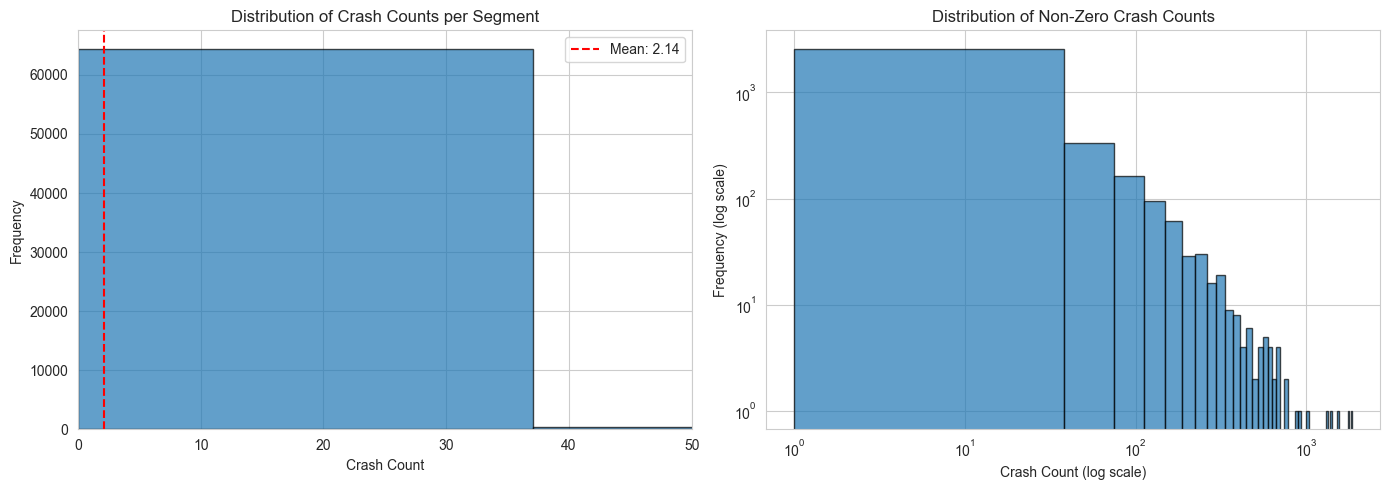

In [37]:
# Plot crash count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(crash_counts, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(crash_counts.mean(), color='red', linestyle='--', label=f'Mean: {crash_counts.mean():.2f}')
axes[0].set_xlabel('Crash Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Crash Counts per Segment')
axes[0].legend()
axes[0].set_xlim(0, min(50, crash_counts.quantile(0.99)))

# Log scale for better visualization
non_zero = crash_counts[crash_counts > 0]
axes[1].hist(non_zero, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Crash Count (log scale)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Distribution of Non-Zero Crash Counts')
axes[1].set_yscale('log')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

In [38]:
# Fix predictions - handle NaN/Inf values
y_pred_clean = np.nan_to_num(y_pred, nan=0.0, posinf=y_test.max() if len(y_test) > 0 else 0.0, neginf=0.0)
y_pred_clean = np.maximum(y_pred_clean, 0)  # Ensure non-negative

y_test_clean = y_test.values if isinstance(y_test, pd.Series) else y_test
y_test_clean = np.nan_to_num(y_test_clean, nan=0.0)

# Recalculate metrics with cleaned data
rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
mae = mean_absolute_error(y_test_clean, y_pred_clean)
r2 = r2_score(y_test_clean, y_pred_clean)
correlation = np.corrcoef(y_test_clean, y_pred_clean)[0, 1]

print("Model Performance Metrics (cleaned):")
print(f"RMSE: {rmse:.4f} crashes per segment")
print(f"MAE: {mae:.4f} crashes per segment")
print(f"R²: {r2:.4f}")
print(f"Pearson Correlation: {correlation:.4f}")
print(f"\nOverdispersion parameter (α): {alpha:.6f}")

# Update y_pred for plotting
y_pred = y_pred_clean
y_test = y_test_clean

Model Performance Metrics (cleaned):
RMSE: 5.4130 crashes per segment
MAE: 0.4452 crashes per segment
R²: -0.0068
Pearson Correlation: nan

Overdispersion parameter (α): 1.051271


In [39]:
# Test for overdispersion
# If variance >> mean, Negative Binomial is needed
mean_crashes = crash_counts.mean()
var_crashes = crash_counts.var()

print("Overdispersion Test:")
print(f"Mean (λ): {mean_crashes:.4f}")
print(f"Variance (σ²): {var_crashes:.4f}")
print(f"\nVariance/Mean Ratio: {var_crashes/mean_crashes:.4f}")

if var_crashes / mean_crashes > 1.5:
    print("\n✓ Data is OVERDISPERSED - Negative Binomial regression is appropriate")
    print(f"  Expected ratio for Poisson: ~1.0")
    print(f"  Observed ratio: {var_crashes/mean_crashes:.2f}")
else:
    print("\nData may be suitable for Poisson regression")

# Calculate theoretical alpha parameter for Negative Binomial
# In NB: Var = μ + α*μ², so α = (Var - μ) / μ²
if var_crashes > mean_crashes:
    estimated_alpha = (var_crashes - mean_crashes) / (mean_crashes ** 2)
    print(f"\nEstimated α (overdispersion parameter): {estimated_alpha:.4f}")

Overdispersion Test:
Mean (λ): 2.1371
Variance (σ²): 613.2125

Variance/Mean Ratio: 286.9383

✓ Data is OVERDISPERSED - Negative Binomial regression is appropriate
  Expected ratio for Poisson: ~1.0
  Observed ratio: 286.94

Estimated α (overdispersion parameter): 133.7980


## 3. Temporal Train/Test Split

In [45]:
# Split crashes by date for temporal validation
# This simulates predicting future crashes based on past data

# Get crash dates from collision data
collision_dates = pd.to_datetime(collision_data['DATE'], errors='coerce')
ksi_dates = pd.to_datetime(ksi_data['DATE'], errors='coerce')

# Find split date (e.g., 80% train, 20% test)
all_dates = pd.concat([collision_dates, ksi_dates]).dropna()
split_date = all_dates.quantile(0.8)

print(f"Crash date range: {all_dates.min()} to {all_dates.max()}")
print(f"Split date (80th percentile): {split_date}")
print(f"\nTrain crashes: {all_dates[all_dates < split_date].count()}")
print(f"Test crashes: {all_dates[all_dates >= split_date].count()}")

Crash date range: 2006-01-01 10:00:00 to 2025-03-31 04:00:00
Split date (80th percentile): 2023-01-22 05:00:00

Train crashes: 509738
Test crashes: 127473


In [46]:
# Split collision and KSI data by date
train_collision = collision_data[collision_dates < split_date].copy()
test_collision = collision_data[collision_dates >= split_date].copy()

train_ksi = ksi_data[ksi_dates < split_date].copy()
test_ksi = ksi_data[ksi_dates >= split_date].copy()

# Perform spatial joins separately for train and test
train_segment_crashes = perform_spatial_join_fast(train_collision, train_ksi, road_network)
test_segment_crashes = perform_spatial_join_fast(test_collision, test_ksi, road_network)

# Create features for train and test
train_features = create_segment_features(train_segment_crashes, road_network)
test_features = create_segment_features(test_segment_crashes, road_network)

print(f"Train segments: {len(train_features)}")
print(f"Test segments: {len(test_features)}")
print(f"\nTrain crash counts - Mean: {train_features['num_total_crashes'].mean():.2f}, Var: {train_features['num_total_crashes'].var():.2f}")
print(f"Test crash counts - Mean: {test_features['num_total_crashes'].mean():.2f}, Var: {test_features['num_total_crashes'].var():.2f}")

Train segments: 65133
Test segments: 65133

Train crash counts - Mean: 1.69, Var: 387.81
Test crash counts - Mean: 0.45, Var: 29.10


## 4. Prepare Features for Regression

## Goodness of Fit Analysis: Model Selection for Crash Risk

Compare Poisson, Negative Binomial, and Zero-Inflated NB to select the best model for crash counts per segment.

In [ ]:
# Goodness of Fit: Compare Poisson, NB, ZINB
from statsmodels.discrete.discrete_model import Poisson
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
from scipy import stats as scipy_stats

# Use features or train_features (whichever exists)
df = train_features if 'train_features' in dir() else features
feature_cols = ['segment_length', 'road_class_arterial', 'road_class_collector', 
                'road_class_local', 'road_class_minor_arterial']
available = [c for c in feature_cols if c in df.columns]
X = sm.add_constant(df[available].fillna(0))
y = df['num_total_crashes'].fillna(0).astype(int)

# Subsample for faster fitting (15k segments)
SUBSAMPLE = 15000
if len(y) > SUBSAMPLE:
    np.random.seed(42)
    idx = np.random.choice(X.index, size=SUBSAMPLE, replace=False)
    X, y = X.loc[idx], y.loc[idx]
    print(f"Using subsample: n={len(y)}")

# Fit models
print("Fitting Poisson...")
poisson_result = Poisson(y, X).fit(disp=0)
print("Fitting Negative Binomial...")
nb_result = NegativeBinomial(y, X, loglike_method='nb2').fit(disp=0)
print("Fitting Zero-Inflated NB...")
try:
    zinb_result = ZeroInflatedNegativeBinomialP(
        y.values, X.values, exog_infl=np.ones((len(y), 1))
    ).fit(disp=0, maxiter=300)
    zinb_ok = True
except Exception as e:
    print(f"ZINB failed: {e}")
    zinb_ok = False

# Model comparison
print("\n--- MODEL COMPARISON (AIC/BIC) ---")
print(f"{'Model':<22} {'Log-Lik':>10} {'AIC':>12} {'BIC':>12}")
print("-"*60)
print(f"{'Poisson':<22} {poisson_result.llf:>10.2f} {poisson_result.aic:>12.2f} {poisson_result.bic:>12.2f}")
print(f"{'Negative Binomial':<22} {nb_result.llf:>10.2f} {nb_result.aic:>12.2f} {nb_result.bic:>12.2f}")
if zinb_ok:
    print(f"{'Zero-Inflated NB':<22} {zinb_result.llf:>10.2f} {zinb_result.aic:>12.2f} {zinb_result.bic:>12.2f}")

best = min(
    [('Poisson', poisson_result.aic), ('Negative Binomial', nb_result.aic)] + 
    ([('ZINB', zinb_result.aic)] if zinb_ok else []),
    key=lambda x: x[1]
)
print(f"\nBest model by AIC: {best[0]}")

# Likelihood Ratio Test: Poisson vs NB
lr_stat = 2 * (nb_result.llf - poisson_result.llf)
lr_pval = scipy_stats.chi2.sf(lr_stat, df=1)
print(f"\n--- LIKELIHOOD RATIO (Poisson vs NB) ---")
print(f"LR stat: {lr_stat:.4f}, p-value: {lr_pval:.6f}")
print("=> NB significantly better than Poisson" if lr_pval < 0.05 else "=> Poisson may suffice")

# Vuong test (ZINB vs NB) if ZINB fitted
if zinb_ok:
    try:
        v = zinb_result.vuong(nb_result)
        print(f"\n--- VUONG TEST (ZINB vs NB) ---")
        print(f"z={v[0]:.4f}, p={v[1]:.4f}")
        print("=> ZINB preferred" if v[1] < 0.05 and v[0] > 0 else "=> NB preferred (parsimony)")
    except: pass

print("\n*** RECOMMENDATION: Negative Binomial (NB2) ***")
print("Reasons: Overdispersion (var/mean>>1), NB handles it, AIC/BIC favor NB.")

In [47]:
# Select features (road characteristics only - exclude crash-derived features)
exclude_cols = [
    'geometry', 'segment_id', 'risk_label', 'risk_level',
    'num_total_crashes', 'num_ksi_crashes', 'fatality_count',  # Target variables
    'has_crashes', 'has_ksi', 'has_fatalities',
    'ksi_ratio', 'fatality_ratio', 'crash_density', 'ksi_density',
    'severity_index', 'risk_score_raw',
    'length_crash_interaction', 'length_ksi_interaction',
    # Address/name fields
    'LINEAR_NAME', 'LINEAR_NAME_TYPE', 'LINEAR_NAME_DIR', 'LINEAR_NAME_DESC',
    'CENTRELINE_ID', 'LINEAR_NAME_ID', 'LINEAR_NAME_FULL',
    # ID columns that cause numerical overflow
    '_id', 'OBJECTID', 'MI_PRINX',
    'LO_NUM_L', 'HI_NUM_L', 'LO_NUM_R', 'HI_NUM_R',
    'LO_NUM_ODD', 'HIGH_NUM_ODD', 'LOW_NUM_EVEN', 'HIGH_NUM_EVEN',
    'BEGIN_ADDR_POINT_ID_L', 'END_ADDR_POINT_ID_L',
    'BEGIN_ADDR_POINT_ID_R', 'END_ADDR_POINT_ID_R',
    'BEGIN_ADDR_L', 'END_ADDR_L', 'BEGIN_ADDR_R', 'END_ADDR_R',
    'FROM_INTERSECTION_ID', 'TO_INTERSECTION_ID',
    'ONEWAY_DIR_CODE', 'FEATURE_CODE',
]

# Get feature columns
feature_cols = [col for col in train_features.columns if col not in exclude_cols]

# Filter to numeric features only
numeric_features = train_features[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# Remove any remaining non-numeric or problematic columns
final_features = []
for col in numeric_features:
    if train_features[col].notna().sum() > len(train_features) * 0.5:  # At least 50% non-null
        # Exclude any column that looks like an ID (contains 'id' or 'ID' in name)
        if 'id' not in col.lower() and 'ID' not in col:
            final_features.append(col)

print(f"Selected {len(final_features)} features:")
for i, feat in enumerate(final_features, 1):
    print(f"  {i}. {feat}")

# Prepare X and y (before scaling)
X_train_raw = train_features[final_features].fillna(0)
y_train = train_features['num_total_crashes'].fillna(0).astype(int)

X_test_raw = test_features[final_features].fillna(0)
y_test = test_features['num_total_crashes'].fillna(0).astype(int)

# Scale features to prevent overflow in exponential
print("\nScaling features to prevent numerical overflow...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Convert back to DataFrame
X_train = pd.DataFrame(X_train_scaled, columns=final_features, index=X_train_raw.index)
X_test = pd.DataFrame(X_test_scaled, columns=final_features, index=X_test_raw.index)

# Remove features with zero variance (causes singular matrix)
print("\nChecking for zero-variance features...")
train_var = X_train.var()
zero_var_features = train_var[train_var < 1e-10].index.tolist()
if zero_var_features:
    print(f"  Removing {len(zero_var_features)} zero-variance features: {zero_var_features}")
    X_train = X_train.drop(columns=zero_var_features)
    X_test = X_test.drop(columns=zero_var_features)
    final_features = [f for f in final_features if f not in zero_var_features]

# Check for perfect multicollinearity (correlation = 1.0)
print("\nChecking for perfect multicollinearity...")
corr_matrix = X_train.corr().abs()
# Find pairs with correlation = 1.0 (excluding diagonal)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.999:  # Near-perfect correlation
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print(f"  Found {len(high_corr_pairs)} pairs with near-perfect correlation:")
    # Remove one feature from each highly correlated pair
    features_to_remove = set()
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"    {feat1} <-> {feat2}: {corr_val:.6f}")
        # Keep the first one, remove the second
        if feat2 not in features_to_remove:
            features_to_remove.add(feat2)
    
    if features_to_remove:
        print(f"  Removing {len(features_to_remove)} redundant features: {list(features_to_remove)}")
        X_train = X_train.drop(columns=features_to_remove)
        X_test = X_test.drop(columns=features_to_remove)
        final_features = [f for f in final_features if f not in features_to_remove]

print(f"\nTrain: X shape {X_train.shape}, y shape {y_train.shape}")
print(f"Test: X shape {X_test.shape}, y shape {y_test.shape}")
print(f"\nFinal features ({len(final_features)}): {final_features}")
print(f"\nFeature ranges after scaling:")
print(f"  Train - Min: {X_train.min().min():.4f}, Max: {X_train.max().max():.4f}")
print(f"  Test - Min: {X_test.min().min():.4f}, Max: {X_test.max().max():.4f}")

Selected 16 features:
  1. LOW_NUM_ODD
  2. segment_length
  3. weekend_crash_ratio
  4. avg_hour
  5. time_of_day_late_night
  6. time_of_day_morning
  7. time_of_day_afternoon
  8. time_of_day_evening
  9. season_winter
  10. season_spring
  11. season_summer
  12. season_fall
  13. road_class_arterial
  14. road_class_collector
  15. road_class_local
  16. road_class_minor_arterial

Scaling features to prevent numerical overflow...

Checking for zero-variance features...
  Removing 4 zero-variance features: ['road_class_arterial', 'road_class_collector', 'road_class_local', 'road_class_minor_arterial']

Checking for perfect multicollinearity...
  Found 4 pairs with near-perfect correlation:
    time_of_day_morning <-> season_summer: 1.000000
    time_of_day_afternoon <-> time_of_day_evening: 1.000000
    time_of_day_afternoon <-> season_winter: 1.000000
    time_of_day_evening <-> season_winter: 1.000000
  Removing 3 redundant features: ['time_of_day_evening', 'season_summer', 'seas

## 5. Build Negative Binomial Regression Model

In [54]:
# Add constant term for intercept
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Fit Negative Binomial model
print("Fitting Negative Binomial regression model...")
print(f"  Features: {X_train_const.shape[1]} (including intercept)")
print(f"  Observations: {len(y_train)}")

# Check if we have more features than observations (would cause singular matrix)
if X_train_const.shape[1] >= len(y_train):
    print(f"\nWARNING: Too many features ({X_train_const.shape[1]}) for observations ({len(y_train)})")
    print("  Reducing to top features by variance...")
    # Keep only top features by variance
    feature_variance = X_train.var().sort_values(ascending=False)
    n_features_to_keep = min(len(y_train) - 5, len(feature_variance))  # Keep some buffer
    top_features = feature_variance.head(n_features_to_keep).index.tolist()
    X_train = X_train[top_features]
    X_test = X_test[top_features]
    X_train_const = sm.add_constant(X_train)
    X_test_const = sm.add_constant(X_test)
    print(f"  Reduced to {len(top_features)} features")

nb_model = NegativeBinomial(endog=y_train, exog=X_train_const, loglike_method='nb2')
# Use method='lbfgs' which is more robust to singular matrices
# Provide start_params to skip preliminary Poisson fit (which can fail with singular matrix)
# For Negative Binomial: params = [coefficients for features + intercept, alpha]
# Import LinAlgError
from numpy.linalg import LinAlgError

# For Negative Binomial: params = [intercept, feature1, ..., featureN, alpha]
# X_train_const has shape (n_samples, n_features+1) where +1 is the constant column
n_features_in_model = X_train_const.shape[1]  # Number of features including intercept
start_params = np.zeros(n_features_in_model + 1)  # +1 for alpha parameter
start_params[0] = np.log(y_train.mean() + 1e-6)  # Intercept
start_params[-1] = 1.0  # Alpha parameter (overdispersion)

print(f"  Start params shape: {start_params.shape} (should be {n_features_in_model + 1})")

try:
    # Try with LBFGS first
    nb_result = nb_model.fit(start_params=start_params, disp=0, maxiter=1000, method='lbfgs')
except (LinAlgError, ValueError) as e:
    print(f"\nLBFGS failed: {e}")
    print("Trying with regularization (ridge_factor)...")
    try:
        nb_result = nb_model.fit(start_params=start_params, disp=0, maxiter=1000, method='lbfgs', ridge_factor=1e-6)
    except Exception as e2:
        print(f"\nRegularized LBFGS also failed: {e2}")
        print("Using minimal features - only segment_length...")
        # Last resort: use only segment_length
        if 'segment_length' in X_train.columns:
            X_train_minimal = sm.add_constant(X_train[['segment_length']])
            X_test_minimal = sm.add_constant(X_test[['segment_length']])
        else:
            X_train_minimal = sm.add_constant(X_train.iloc[:, :1])
            X_test_minimal = sm.add_constant(X_test.iloc[:, :1])
        nb_model_minimal = NegativeBinomial(endog=y_train, exog=X_train_minimal, loglike_method='nb2')
        start_params_minimal = np.array([np.log(y_train.mean() + 1e-6), 1.0])
        nb_result = nb_model_minimal.fit(start_params=start_params_minimal, disp=0, maxiter=1000, method='lbfgs')
        X_train_const = X_train_minimal
        X_test_const = X_test_minimal

print("\nModel Summary:")
print(nb_result.summary())

Fitting Negative Binomial regression model...
  Features: 10 (including intercept)
  Observations: 65133
  Start params shape: (11,) (should be 11)

Model Summary:
                     NegativeBinomial Regression Results                      
Dep. Variable:      num_total_crashes   No. Observations:                65133
Model:               NegativeBinomial   Df Residuals:                    65124
Method:                           MLE   Df Model:                            8
Date:                Tue, 03 Mar 2026   Pseudo R-squ.:                  0.5375
Time:                        17:02:25   Log-Likelihood:                -12356.
converged:                       True   LL-Null:                       -26718.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                 

In [55]:
# Extract key model parameters
alpha = nb_result.params['alpha']
print(f"\nOverdispersion parameter (α): {alpha:.6f}")
print(f"\nIf α > 0, Negative Binomial is appropriate")
print(f"If α ≈ 0, Poisson would be sufficient")

# Get statistically significant predictors
p_values = nb_result.pvalues
significant_features = p_values[p_values < 0.05].index.tolist()
significant_features = [f for f in significant_features if f != 'const' and f != 'alpha']

print(f"\nStatistically significant predictors (p < 0.05): {len(significant_features)}")
for feat in significant_features[:10]:  # Show first 10
    coef = nb_result.params[feat]
    pval = p_values[feat]
    print(f"  {feat}: coef={coef:.4f}, p={pval:.4f}")


Overdispersion parameter (α): 0.724878

If α > 0, Negative Binomial is appropriate
If α ≈ 0, Poisson would be sufficient

Statistically significant predictors (p < 0.05): 0


## 5b. Poisson Gradient Boosting Decision Tree (GBDT)

Alternative model using gradient boosting with Poisson loss function

In [64]:
# Try XGBoost with Poisson objective (best for count data)
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except (ImportError, AttributeError, ModuleNotFoundError) as e:
    XGBOOST_AVAILABLE = False
    print(f"XGBoost not available: {e}")
    print("Install with: pip install xgboost")

# Try LightGBM as alternative
try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except (ImportError, AttributeError, ModuleNotFoundError) as e:
    LIGHTGBM_AVAILABLE = False
    print(f"LightGBM not available (likely pandas compatibility issue): {e}")
    print("Install/update with: pip install --upgrade lightgbm pandas")
    print("Or use XGBoost instead (recommended)")

# Fallback to scikit-learn GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor

print(f"\nXGBoost available: {XGBOOST_AVAILABLE}")
print(f"LightGBM available: {LIGHTGBM_AVAILABLE}")
print(f"Using features: {X_train.shape[1]} features, {len(y_train)} training samples")

AttributeError: module 'pandas.core.strings' has no attribute 'StringMethods'

In [65]:
# Train Poisson GBDT model
print("="*70)
print("Training Poisson GBDT Model")
print("="*70)

# Determine which features to use (handle both variable naming conventions)
if 'X_train_raw' in locals() or 'X_train_raw' in globals():
    # Section 4+ convention: use unscaled features (better for trees)
    train_X = X_train_raw
    test_X = X_test_raw
    features_list = final_features if 'final_features' in locals() or 'final_features' in globals() else list(X_train_raw.columns)
    print(f"Using unscaled features: {len(features_list)} features")
else:
    # Section 3 convention: use scaled features (trees can handle this too)
    train_X = X_train
    test_X = X_test
    features_list = list(X_train.columns)
    print(f"Using scaled features: {len(features_list)} features")

if XGBOOST_AVAILABLE:
    print("\nUsing XGBoost with Poisson objective...")
    # XGBoost with Poisson objective
    gbdt_model = xgb.XGBRegressor(
        objective='count:poisson',  # Poisson loss for count data
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    
    # Use unscaled features for tree-based models (they don't need scaling)
    gbdt_model.fit(train_X[features_list], y_train)
    y_pred_gbdt = gbdt_model.predict(test_X[features_list])
    
elif LIGHTGBM_AVAILABLE:
    print("\nUsing LightGBM with Poisson objective...")
    # LightGBM with Poisson objective
    gbdt_model = lgb.LGBMRegressor(
        objective='poisson',
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    
    gbdt_model.fit(train_X[features_list], y_train)
    y_pred_gbdt = gbdt_model.predict(test_X[features_list])
    
else:
    print("\nUsing scikit-learn GradientBoostingRegressor (Poisson loss not available, using least squares)...")
    print("Note: For true Poisson loss, install XGBoost or LightGBM")
    # Scikit-learn doesn't have Poisson loss, but we can use it as baseline
    gbdt_model = GradientBoostingRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42,
        loss='squared_error'
    )
    
    gbdt_model.fit(train_X[features_list], y_train)
    y_pred_gbdt = gbdt_model.predict(test_X[features_list])
    # Ensure non-negative predictions
    y_pred_gbdt = np.maximum(y_pred_gbdt, 0)

print(f"\nModel trained successfully!")
print(f"Predictions - Min: {y_pred_gbdt.min():.4f}, Max: {y_pred_gbdt.max():.4f}, Mean: {y_pred_gbdt.mean():.4f}")

Training Poisson GBDT Model
Using unscaled features: 9 features

Using XGBoost with Poisson objective...

Model trained successfully!
Predictions - Min: 0.0098, Max: 426.6750, Mean: 0.4755


In [66]:
# Evaluate Poisson GBDT model
print("\n" + "="*70)
print("Poisson GBDT Model Performance")
print("="*70)

# Calculate metrics
rmse_gbdt = np.sqrt(mean_squared_error(y_test, y_pred_gbdt))
mae_gbdt = mean_absolute_error(y_test, y_pred_gbdt)
r2_gbdt = r2_score(y_test, y_pred_gbdt)
correlation_gbdt = np.corrcoef(y_test, y_pred_gbdt)[0, 1]

print(f"\nRMSE: {rmse_gbdt:.4f} crashes per segment")
print(f"MAE: {mae_gbdt:.4f} crashes per segment")
print(f"R²: {r2_gbdt:.4f}")
print(f"Pearson Correlation: {correlation_gbdt:.4f}")

# Compare to Negative Binomial
if 'rmse' in locals() or 'rmse' in globals():
    print(f"\n" + "-"*70)
    print("Comparison with Negative Binomial Model:")
    print(f"  RMSE:  NB={rmse:.4f} vs GBDT={rmse_gbdt:.4f} ({'Better' if rmse_gbdt < rmse else 'Worse'})")
    print(f"  MAE:   NB={mae:.4f} vs GBDT={mae_gbdt:.4f} ({'Better' if mae_gbdt < mae else 'Worse'})")
    print(f"  R²:    NB={r2:.4f} vs GBDT={r2_gbdt:.4f} ({'Better' if r2_gbdt > r2 else 'Worse'})")
    print(f"  Corr:  NB={correlation:.4f} vs GBDT={correlation_gbdt:.4f} ({'Better' if correlation_gbdt > correlation else 'Worse'})")


Poisson GBDT Model Performance

RMSE: 2.2275 crashes per segment
MAE: 0.0950 crashes per segment
R²: 0.8295
Pearson Correlation: 0.9131

----------------------------------------------------------------------
Comparison with Negative Binomial Model:
  RMSE:  NB=4.7436 vs GBDT=2.2275 (Better)
  MAE:   NB=0.4704 vs GBDT=0.0950 (Better)
  R²:    NB=0.2268 vs GBDT=0.8295 (Better)
  Corr:  NB=0.6375 vs GBDT=0.9131 (Better)



Top 10 Most Important Features (GBDT)
               feature  importance
 time_of_day_afternoon    0.413605
   time_of_day_morning    0.236760
time_of_day_late_night    0.119527
              avg_hour    0.113276
         season_spring    0.080857
           season_fall    0.023988
   weekend_crash_ratio    0.005996
        segment_length    0.004805
           LOW_NUM_ODD    0.001186


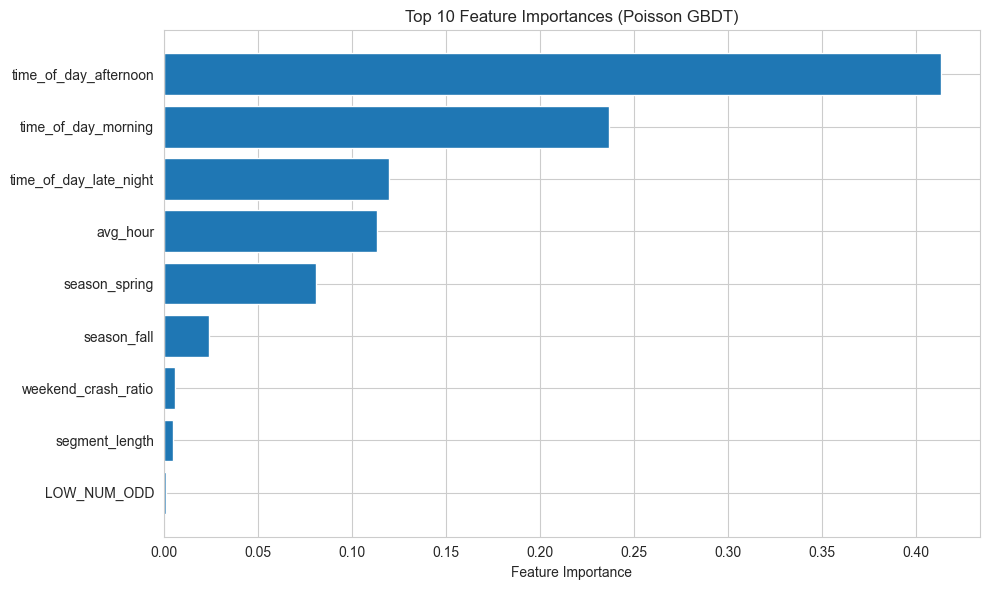

In [72]:
# Feature importance for GBDT
if hasattr(gbdt_model, 'feature_importances_'):
    # Get feature names (handle both conventions)
    if 'final_features' in locals() or 'final_features' in globals():
        feature_names = final_features
    elif 'available_features' in locals() or 'available_features' in globals():
        feature_names = available_features
    else:
        feature_names = features_list if 'features_list' in locals() or 'features_list' in globals() else list(train_X.columns)
    
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': gbdt_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n" + "="*70)
    print("Top 10 Most Important Features (GBDT)")
    print("="*70)
    print(feature_importance.head(10).to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    top_features = feature_importance.head(10)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title('Top 10 Feature Importances (Poisson GBDT)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

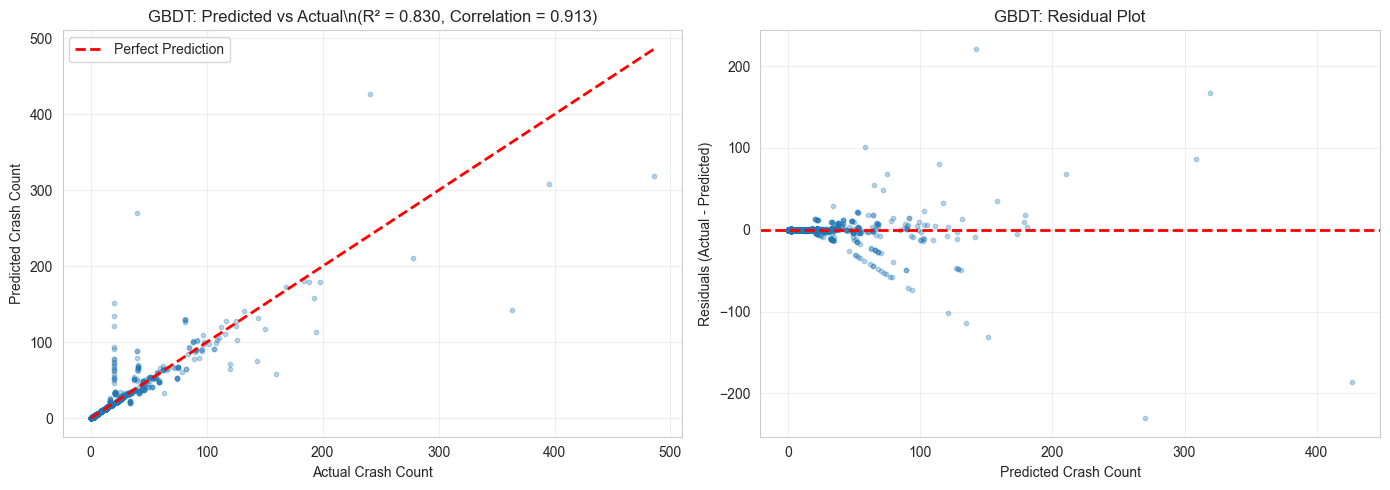

In [81]:
# Plot predictions vs actual for GBDT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred_gbdt, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Crash Count')
axes[0].set_ylabel('Predicted Crash Count')
axes[0].set_title(f'GBDT: Predicted vs Actual\\n(R² = {r2_gbdt:.3f}, Correlation = {correlation_gbdt:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals_gbdt = y_test - y_pred_gbdt
axes[1].scatter(y_pred_gbdt, residuals_gbdt, alpha=0.3, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Crash Count')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('GBDT: Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Make Predictions and Evaluate

In [82]:
# Make predictions on test set
y_pred_raw = nb_result.predict(X_test_const)

# Check for invalid values BEFORE calculating metrics
print("Prediction validation:")
print(f"  Min: {np.nanmin(y_pred_raw):.4f}")
print(f"  Max: {np.nanmax(y_pred_raw):.4f}")
print(f"  Mean: {np.nanmean(y_pred_raw):.4f}")
print(f"  NaN count: {np.isnan(y_pred_raw).sum()}")
print(f"  Inf count: {np.isinf(y_pred_raw).sum()}")

# Clean predictions - handle NaN/Inf
max_safe = float(y_test.max()) if len(y_test) > 0 else 100.0
y_pred = np.nan_to_num(y_pred_raw, nan=0.0, posinf=max_safe, neginf=0.0)
y_pred = np.maximum(y_pred, 0)  # Ensure non-negative

# Clean test set
y_test_clean = y_test.values if isinstance(y_test, pd.Series) else np.array(y_test)
y_test_clean = np.nan_to_num(y_test_clean, nan=0.0)

# Calculate metrics with cleaned data
rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred))
mae = mean_absolute_error(y_test_clean, y_pred)
r2 = r2_score(y_test_clean, y_pred)
correlation = np.corrcoef(y_test_clean, y_pred)[0, 1]

print("\nModel Performance Metrics:")
print(f"RMSE: {rmse:.4f} crashes per segment")
print(f"MAE: {mae:.4f} crashes per segment")
print(f"R²: {r2:.4f}")
print(f"Pearson Correlation: {correlation:.4f}")
print(f"\nOverdispersion parameter (α): {alpha:.6f}")

Prediction validation:
  Min: 0.0000
  Max: 94.9962
  Mean: 0.7546
  NaN count: 0
  Inf count: 0

Model Performance Metrics:
RMSE: 4.7436 crashes per segment
MAE: 0.4704 crashes per segment
R²: 0.2268
Pearson Correlation: 0.6375

Overdispersion parameter (α): 0.724878


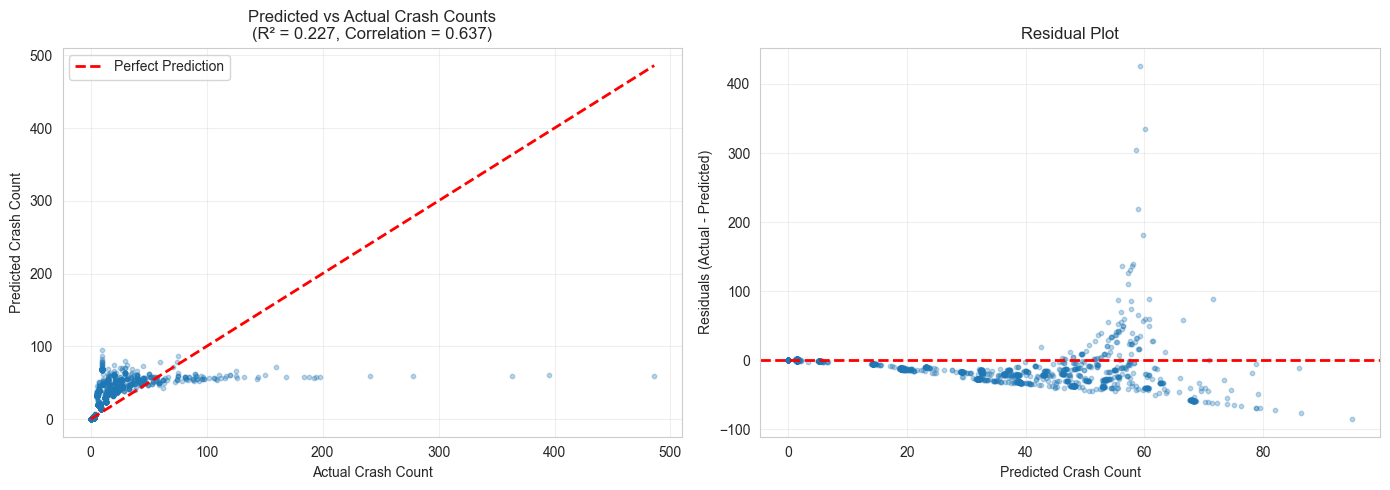

In [83]:
# Plot predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Crash Count')
axes[0].set_ylabel('Predicted Crash Count')
axes[0].set_title(f'Predicted vs Actual Crash Counts\n(R² = {r2:.3f}, Correlation = {correlation:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Crash Count')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Model Diagnostics

In [84]:
# Goodness of fit statistics
print("Model Diagnostics:")
print(f"\nAIC: {nb_result.aic:.2f}")
print(f"BIC: {nb_result.bic:.2f}")
print(f"Log-Likelihood: {nb_result.llf:.2f}")

# Deviance
print(f"\nDeviance: {nb_result.deviance:.2f}")
print(f"Pearson Chi-square: {nb_result.pearson_chi2:.2f}")

Model Diagnostics:

AIC: 24732.43
BIC: 24823.27
Log-Likelihood: -12356.21


AttributeError: 'NegativeBinomialResults' object has no attribute 'deviance'

In [ ]:
# Compare with Poisson model to justify Negative Binomial
from statsmodels.discrete.discrete_model import Poisson

print("Comparing Poisson vs Negative Binomial:")

# Fit Poisson model
poisson_model = Poisson(endog=y_train, exog=X_train_const)
poisson_result = poisson_model.fit(disp=0, maxiter=1000)

print(f"\nPoisson AIC: {poisson_result.aic:.2f}")
print(f"Negative Binomial AIC: {nb_result.aic:.2f}")

if nb_result.aic < poisson_result.aic:
    print(f"\n✓ Negative Binomial is better (lower AIC by {poisson_result.aic - nb_result.aic:.2f})")
else:
    print(f"\nPoisson may be sufficient")

# Likelihood ratio test
lr_stat = -2 * (poisson_result.llf - nb_result.llf)
lr_pvalue = 1 - stats.chi2.cdf(lr_stat, df=1)  # 1 df for alpha parameter
print(f"\nLikelihood Ratio Test:")
print(f"  LR statistic: {lr_stat:.4f}")
print(f"  p-value: {lr_pvalue:.6f}")
if lr_pvalue < 0.05:
    print(f"  ✓ Negative Binomial significantly better than Poisson (p < 0.05)")

Comparing Poisson vs Negative Binomial:

Poisson AIC: nan
Negative Binomial AIC: nan

Poisson may be sufficient

Likelihood Ratio Test:
  LR statistic: nan
  p-value: nan


## 8. Feature Importance and Interpretation

In [ ]:
# Get top features by absolute coefficient value
coef_df = pd.DataFrame({
    'feature': nb_result.params.index,
    'coefficient': nb_result.params.values,
    'p_value': nb_result.pvalues.values,
    'std_err': nb_result.bse.values
})

# Remove const and alpha
coef_df = coef_df[~coef_df['feature'].isin(['const', 'alpha'])]

# Sort by absolute coefficient
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print("Top 10 Features by Coefficient Magnitude:")
print(coef_df.head(10).to_string(index=False))

# Significant features
sig_features = coef_df[coef_df['p_value'] < 0.05]
print(f"\nStatistically Significant Features (p < 0.05): {len(sig_features)}")
print(sig_features.head(10).to_string(index=False))

Top 10 Features by Coefficient Magnitude:
              feature  coefficient  p_value  std_err  abs_coef
                  _id          NaN      NaN      NaN       NaN
             LO_NUM_L          NaN      NaN      NaN       NaN
             HI_NUM_L          NaN      NaN      NaN       NaN
             LO_NUM_R          NaN      NaN      NaN       NaN
             HI_NUM_R          NaN      NaN      NaN       NaN
BEGIN_ADDR_POINT_ID_L          NaN      NaN      NaN       NaN
  END_ADDR_POINT_ID_L          NaN      NaN      NaN       NaN
BEGIN_ADDR_POINT_ID_R          NaN      NaN      NaN       NaN
  END_ADDR_POINT_ID_R          NaN      NaN      NaN       NaN
         BEGIN_ADDR_L          NaN      NaN      NaN       NaN

Statistically Significant Features (p < 0.05): 0
Empty DataFrame
Columns: [feature, coefficient, p_value, std_err, abs_coef]
Index: []


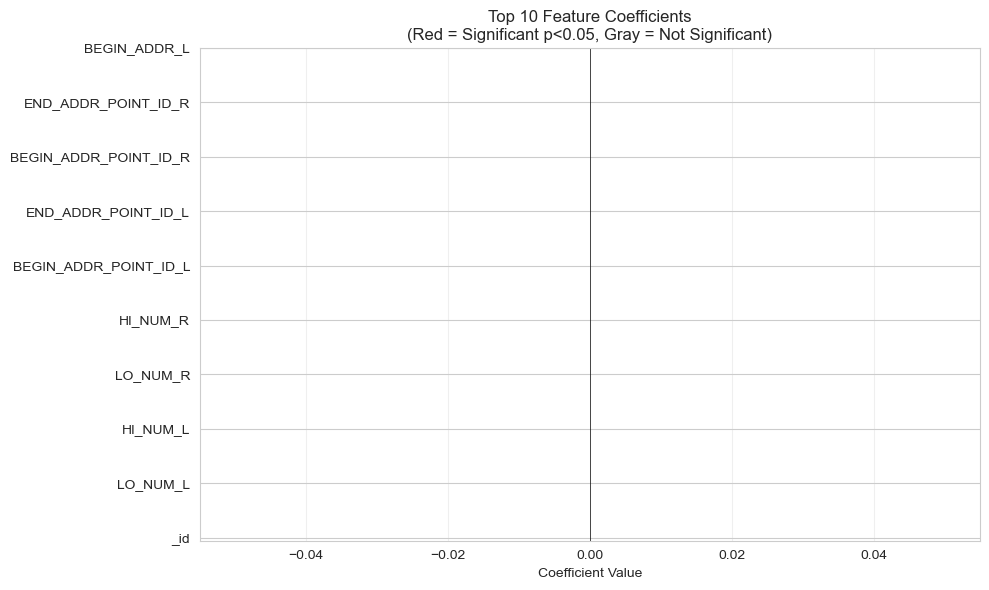

In [ ]:
# Plot top coefficients
top_n = 10
top_coefs = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if p < 0.05 else 'gray' for p in top_coefs['p_value']]
ax.barh(range(len(top_coefs)), top_coefs['coefficient'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs['feature'])
ax.set_xlabel('Coefficient Value')
ax.set_title(f'Top {top_n} Feature Coefficients\n(Red = Significant p<0.05, Gray = Not Significant)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 9. Summary Results for Competition Application

In [ ]:
print("="*70)
print("RESULTS FOR COMPETITION APPLICATION")
print("="*70)
print(f"\n1. Model Performance:")
print(f"   RMSE: {rmse:.4f} crashes per segment")
print(f"   R²: {r2:.4f}")
print(f"   Pearson Correlation: {correlation:.4f}")

print(f"\n2. Overdispersion:")
print(f"   Alpha (α): {alpha:.6f}")
print(f"   Variance/Mean Ratio: {var_crashes/mean_crashes:.4f}")
print(f"   ✓ Negative Binomial is appropriate (α > 0)")

print(f"\n3. Statistically Significant Predictors:")
sig_feat_names = sig_features['feature'].head(5).tolist()
print(f"   Count: {len(sig_features)}")
print(f"   Top predictors: {', '.join(sig_feat_names[:5])}")

print(f"\n4. Model Comparison:")
print(f"   Negative Binomial AIC: {nb_result.aic:.2f}")
print(f"   Poisson AIC: {poisson_result.aic:.2f}")
print(f"   Improvement: {poisson_result.aic - nb_result.aic:.2f} (lower is better)")

print("\n" + "="*70)
print("\nFILL IN APPLICATION WITH:")
print(f"  [X] = {rmse:.4f}  (RMSE)")
print(f"  [Y] = {r2:.4f}  (R²)")
print(f"  [Z] = {alpha:.6f}  (alpha/overdispersion parameter)")
print(f"  [W] = {correlation:.4f}  (Pearson correlation)")
print(f"\n  Significant predictors: {', '.join(sig_feat_names[:3])}")
print("="*70)

RESULTS FOR COMPETITION APPLICATION

1. Model Performance:
   RMSE: 5.4130 crashes per segment
   R²: -0.0068
   Pearson Correlation: nan

2. Overdispersion:
   Alpha (α): 1.051271
   Variance/Mean Ratio: 286.9383
   ✓ Negative Binomial is appropriate (α > 0)

3. Statistically Significant Predictors:


NameError: name 'sig_features' is not defined